In [14]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

df=pd.read_csv("../data/data.csv", header=None)

In [31]:
def predict(x, w, b):
    return x*w+b

def compute_loss(y_hat, y, delta=5):
    if abs(y_hat - y)<delta:
        loss = 0.5*(y_hat - y)*(y_hat - y)
    else: 
        loss = delta*abs(y_hat-y) - 0.5*delta*delta
    return loss

def grad_MSE(x, y_hat, y):
    dw=x*(y_hat-y)
    db=y_hat-y
    return (dw, db)

def grad_MAE(x, y_hat, y, delta=5):
    dw = delta*x*(y_hat-y)/abs(y_hat-y)
    db = delta*(y_hat-y)/abs(y_hat-y)
    
    return (dw, db)

def gradient_compute(y_hat, y, x, delta=5):
    if abs(y_hat - y)<delta:
        dw, db = grad_MSE(x, y_hat, y) 
    else: 
        dw, db= grad_MAE(x, y_hat, y, delta=5)
    return (dw, db)

def update_weight(w, b, lr, dw, db):
    w_new=w-lr*dw
    b_new=b-lr*db
    return (w_new, b_new)

In [35]:
def plot_chart( w, b, x_values=[3.5, 4.6, 5.5, 6.7], y_values=[4.6, 5.9, 6.7, 9.1]) -> None:
    line_x = [3.0, 7.0]
    line_y = [predict(x, w, b) for x in line_x]

    plt.scatter(x_values, y_values)
    plt.plot(line_x, line_y, color="red")

    equation = f"y = {w:.2f}x + {b:.2f}"
    plt.text(line_x[0]+0.7, line_y[0] + 0.5, equation, color="red")

    plt.xlim(2.8, 7.2)
    plt.ylim(-3, 9.6)
    plt.show()

def one_sample_training_using_huber_loss():
    # Initialization
    b = 0.4
    w=-0.34
    lr=0.01
    
    # How long
    epoch_max=10
    data_size=4
    
    # Training Data
    X_values=df.iloc[:, 0].to_numpy()
    y_values=df.iloc[:, 1].to_numpy()
    losses=[]

    for epoch in range(epoch_max):
        for i in range(data_size):
            x=X_values[i]
            y=y_values[i]

            y_hat=predict(x, w, b)
            
            dw, db=gradient_compute(y_hat, y, x)
            
            w, b = update_weight(w, b, lr, dw, db)

            loss=compute_loss(y_hat, y)
            losses.append(loss)
    plot_chart(w, b, X_values, y_values)
    plt.plot(losses)
    plt.show()

In [ ]:
def mini_batch_training(m=2):
    # Initialization
    b = 0.04
    w=-0.34
    lr=0.01
    # How long
    epoch_max=30
    data_size=4
    # Training Data
    X_values=[6.7, 4.6, 3.5, 5.5]
    y_values=[9.1, 5.9, 4.6, 6.7]
    N=4
    losses=[]
    # Implementation
    for _ in range(epoch_max):
        for i in range(0, N, m):
            dw, db = [], []
            loss_total=0
            for j in range(m):
                X=X_values[i+j]
                y=y_values[i+j]

                y_hat=predict(X, w, b)
                loss_total+=compute_loss(y_hat, y)
                
                grad_w, grad_b = gradient_compute(y_hat, y, X)
                dw.append(grad_w)
                db.append(grad_b)

            losses.append(loss_total/m)
            combined_dw=sum(dw)/m
            combined_db=sum(db)/m
            w, b = update_weight(w, b, lr, combined_dw, combined_db)
    print(losses[:5])
    plt.plot(losses)
    plt.show()
    

[28.802500000000002, 22.118017626953122, 15.625614587082662, 9.79400110680475, 5.520393083097618]


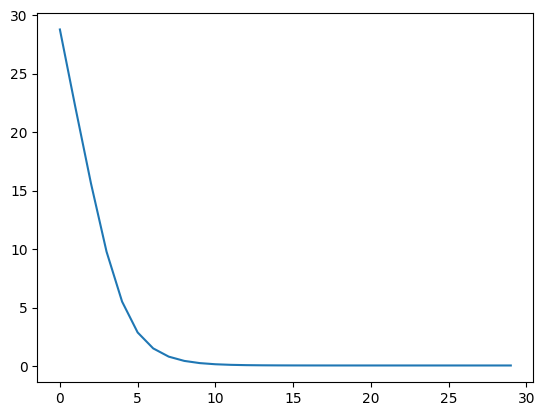

In [72]:
mini_batch_training(4)

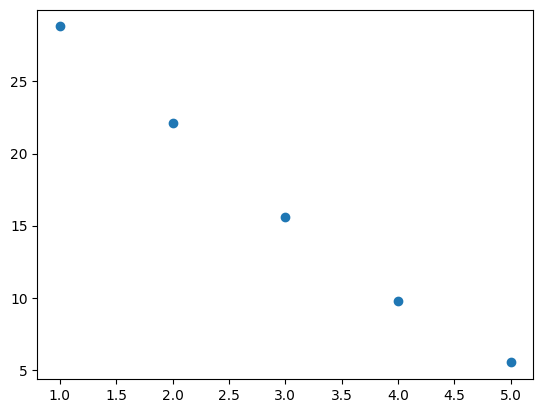

In [69]:
line_x = [1,2,3,4,5]
line_y = [28.802500000000002, 22.118017626953122, 15.625614587082662, 9.79400110680475, 5.520393083097618]

plt.scatter(line_x, line_y)